In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#data files
file_noise="/data/whd02/niyiyu_data/PNWML/noise/waveforms.hdf5";
file_comcat=  "/data/whd02/niyiyu_data/PNWML/comcat/waveforms.hdf5";
file_exotic="/data/whd02/niyiyu_data/PNWML/exotic/waveforms.hdf5";

# metadata
# accessing the comcat metadata
comcat_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/comcat/metadata.csv")
# comcat_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/comcat_metadata.csv")

# accessing the exotic metadata
exotic_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/exotic/metadata.csv")
# exotic_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/exotic_metadata.csv")

# accessing the data files
metadata_noise = pd.read_csv("/data/whd02/niyiyu_data/PNWML/noise/metadata.csv")
# metadata_noise = pd.read_csv("/data/whd01/yiyu_data/PNWML/noise_metadata.csv")

# creating individual data frames for each class

cat_exp = comcat_metadata[comcat_metadata['source_type'] == 'explosion']
cat_eq = comcat_metadata[comcat_metadata['source_type'] == 'earthquake']
cat_su = exotic_metadata[exotic_metadata['source_type'] == 'surface event']
cat_noise = metadata_noise
cat_noise['event_id'] = [cat_noise['trace_start_time'][i]+'_noise' for i in range(len(cat_noise))]

In [5]:
pd.set_option('display.max_columns', None)
cat_su = exotic_metadata[exotic_metadata['source_type'] == 'thunder']

In [11]:
cat_su

,event_id,source_type,station_network_code,station_channel_code,station_code,station_location_code,station_latitude_deg,station_longitude_deg,station_elevation_m,trace_name,trace_sampling_rate_hz,trace_start_time,trace_S_arrival_sample,trace_S_onset,trace_P_arrival_sample,trace_P_onset,trace_snr_db,snr_E,snr_N,snr_Z
0,pnsn3166678,thunder,CC,BH,CPCO,--,43.722,-121.233,2135.0,"bucket3$0,:3,:18001",100,2021-08-02T03:16:29.000000Z,NaN,NaN,7000.0,emergent,23.922|19.759|28.482,23.922,19.759,28.482
1,pnsn3166673,thunder,UW,EH,NCO,--,43.704,-121.140,1908.0,"bucket3$1,:3,:18001",100,2021-08-02T03:05:54.000000Z,NaN,NaN,7000.0,emergent,nan|nan|18.054,NaN,NaN,18.054
2,pnsn3165628,thunder,CC,BH,CPCO,--,43.722,-121.233,2135.0,"bucket3$2,:3,:18001",100,2021-07-26T12:36:45.000000Z,NaN,NaN,7000.0,impulsive,13.149|20.561|19.350,13.149,20.561,19.350
3,pnsn3165633,thunder,CC,BH,CPCO,--,43.722,-121.233,2135.0,"bucket3$3,:3,:18001",100,2021-07-26T12:29:35.000000Z,NaN,NaN,7000.0,emergent,6.389|6.103|3.934,6.389,6.103,3.934
4,pnsn3162793,thunder,CC,BH,TMBU,--,43.602,-121.145,1743.0,"bucket3$4,:3,:18001",100,2021-06-24T15:00:18.000000Z,NaN,NaN,7000.0,emergent,2.768|0.671|1.021,2.768,0.671,1.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,pnsn1426308,thunder,CC,BH,SWNB,--,43.673,-121.355,1569.0,"bucket3$141,:3,:18001",100,2012-08-06T03:42:27.000000Z,NaN,NaN,7000.0,emergent,-2.209|5.502|2.564,-2.209,5.502,2.564
142,pnsn1426303,thunder,CC,BH,WIFE,--,44.060,-121.817,1955.0,"bucket3$142,:3,:18001",100,2012-08-06T02:47:25.000000Z,NaN,NaN,7000.0,emergent,-4.264|0.117|4.859,-4.264,0.117,4.859
143,pnsn1460358,thunder,UW,EH,EDM,--,46.197,-122.151,1609.0,"bucket3$143,:3,:18001",100,2012-04-23T09:16:14.000000Z,NaN,NaN,7000.0,emergent,nan|nan|12.845,NaN,NaN,12.845
144,pnsn1138608,thunder,CC,BH,VALT,--,46.214,-122.189,1681.0,"bucket3$144,:3,:18001",100,2012-04-23T09:12:26.000000Z,NaN,NaN,7000.0,impulsive,9.598|6.667|18.198,9.598,6.667,18.198


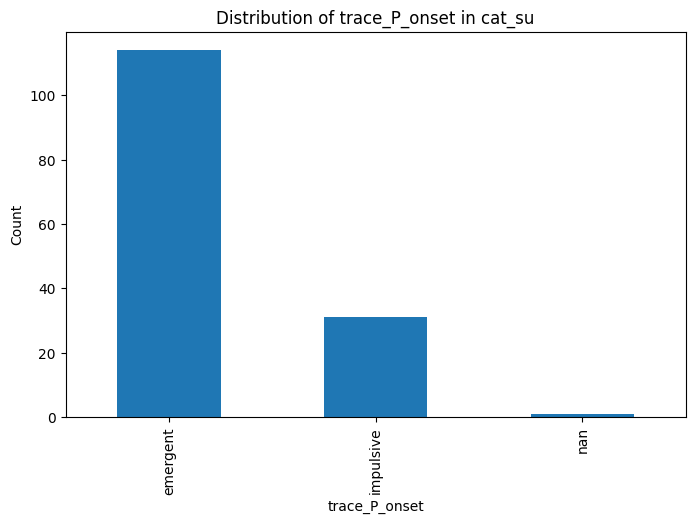

In [7]:
# Plot a histogram of the 'trace_P_onset' field in cat_su

# First, ensure that the 'trace_P_onset' column is read as a string and check unique values
# If 'trace_P_onset' contains categorical values such as 'emergent', 'impulsive', etc., plot their counts as a bar plot

plt.figure(figsize=(8, 5))
cat_su['trace_P_onset'].value_counts(dropna=False).plot(kind='bar')
plt.xlabel('trace_P_onset')
plt.ylabel('Count')
plt.title('Distribution of trace_P_onset in cat_su')
plt.show()

In [8]:
# Split by onset
impulsive = cat_su[cat_su['trace_P_onset'] == 'impulsive'].copy()
emergent = cat_su[cat_su['trace_P_onset'] == 'emergent'].copy()

# Compare pick availability
print("Impulsive - P pick NaN rate:", impulsive['trace_P_arrival_sample'].isna().mean())
print("Emergent  - P pick NaN rate:", emergent['trace_P_arrival_sample'].isna().mean())

def parse_snr(snr_str, component='Z'):
    comp_idx = {'E': 0, 'N': 1, 'Z': 2}
    try:
        parts = str(snr_str).split('|')
        return float(parts[comp_idx[component]])
    except (ValueError, IndexError, AttributeError):
        return np.nan

for comp in ['E', 'N', 'Z']:
    cat_su[f'snr_{comp}'] = cat_su['trace_snr_db'].apply(
        lambda x: parse_snr(x, comp)
    )

impulsive = cat_su[cat_su['trace_P_onset'] == 'impulsive'].copy()
emergent  = cat_su[cat_su['trace_P_onset'] == 'emergent'].copy()

print("Impulsive SNR (Z):\n", impulsive['snr_Z'].describe())
print("\nEmergent  SNR (Z):\n", emergent['snr_Z'].describe())

Impulsive - P pick NaN rate: 0.0
Emergent  - P pick NaN rate: 0.0
Impulsive SNR (Z):
 count    31.000000
mean     20.709935
std       8.333925
min       0.663000
25%      15.469000
50%      19.350000
75%      27.824000
max      37.051000
Name: snr_Z, dtype: float64

Emergent  SNR (Z):
 count    114.000000
mean      11.418228
std       10.126289
min       -9.043000
25%        5.237000
50%        9.694500
75%       17.548000
max       43.313000
Name: snr_Z, dtype: float64


/tmp/ipykernel_3347555/84663793.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_su[f'snr_{comp}'] = cat_su['trace_snr_db'].apply(
/tmp/ipykernel_3347555/84663793.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_su[f'snr_{comp}'] = cat_su['trace_snr_db'].apply(
/tmp/ipykernel_3347555/84663793.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

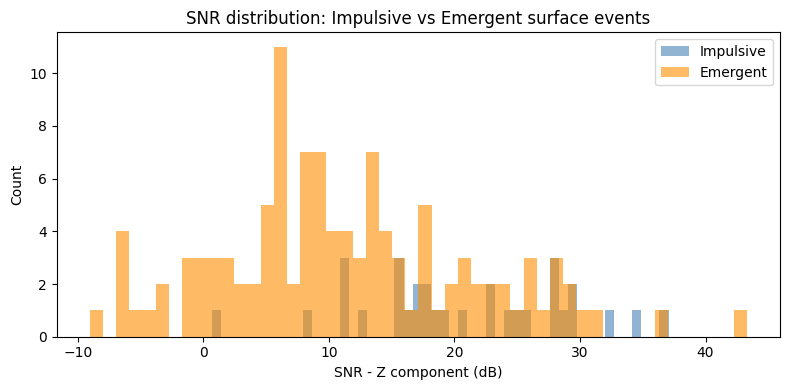

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(impulsive['snr_Z'].dropna(), bins=50, alpha=0.6, label='Impulsive', color='steelblue')
plt.hist(emergent['snr_Z'].dropna(),  bins=50, alpha=0.6, label='Emergent',  color='darkorange')
plt.xlabel("SNR - Z component (dB)")
plt.ylabel("Count")
plt.title("SNR distribution: Impulsive vs Emergent surface events")
plt.legend()
plt.tight_layout()
plt.show()

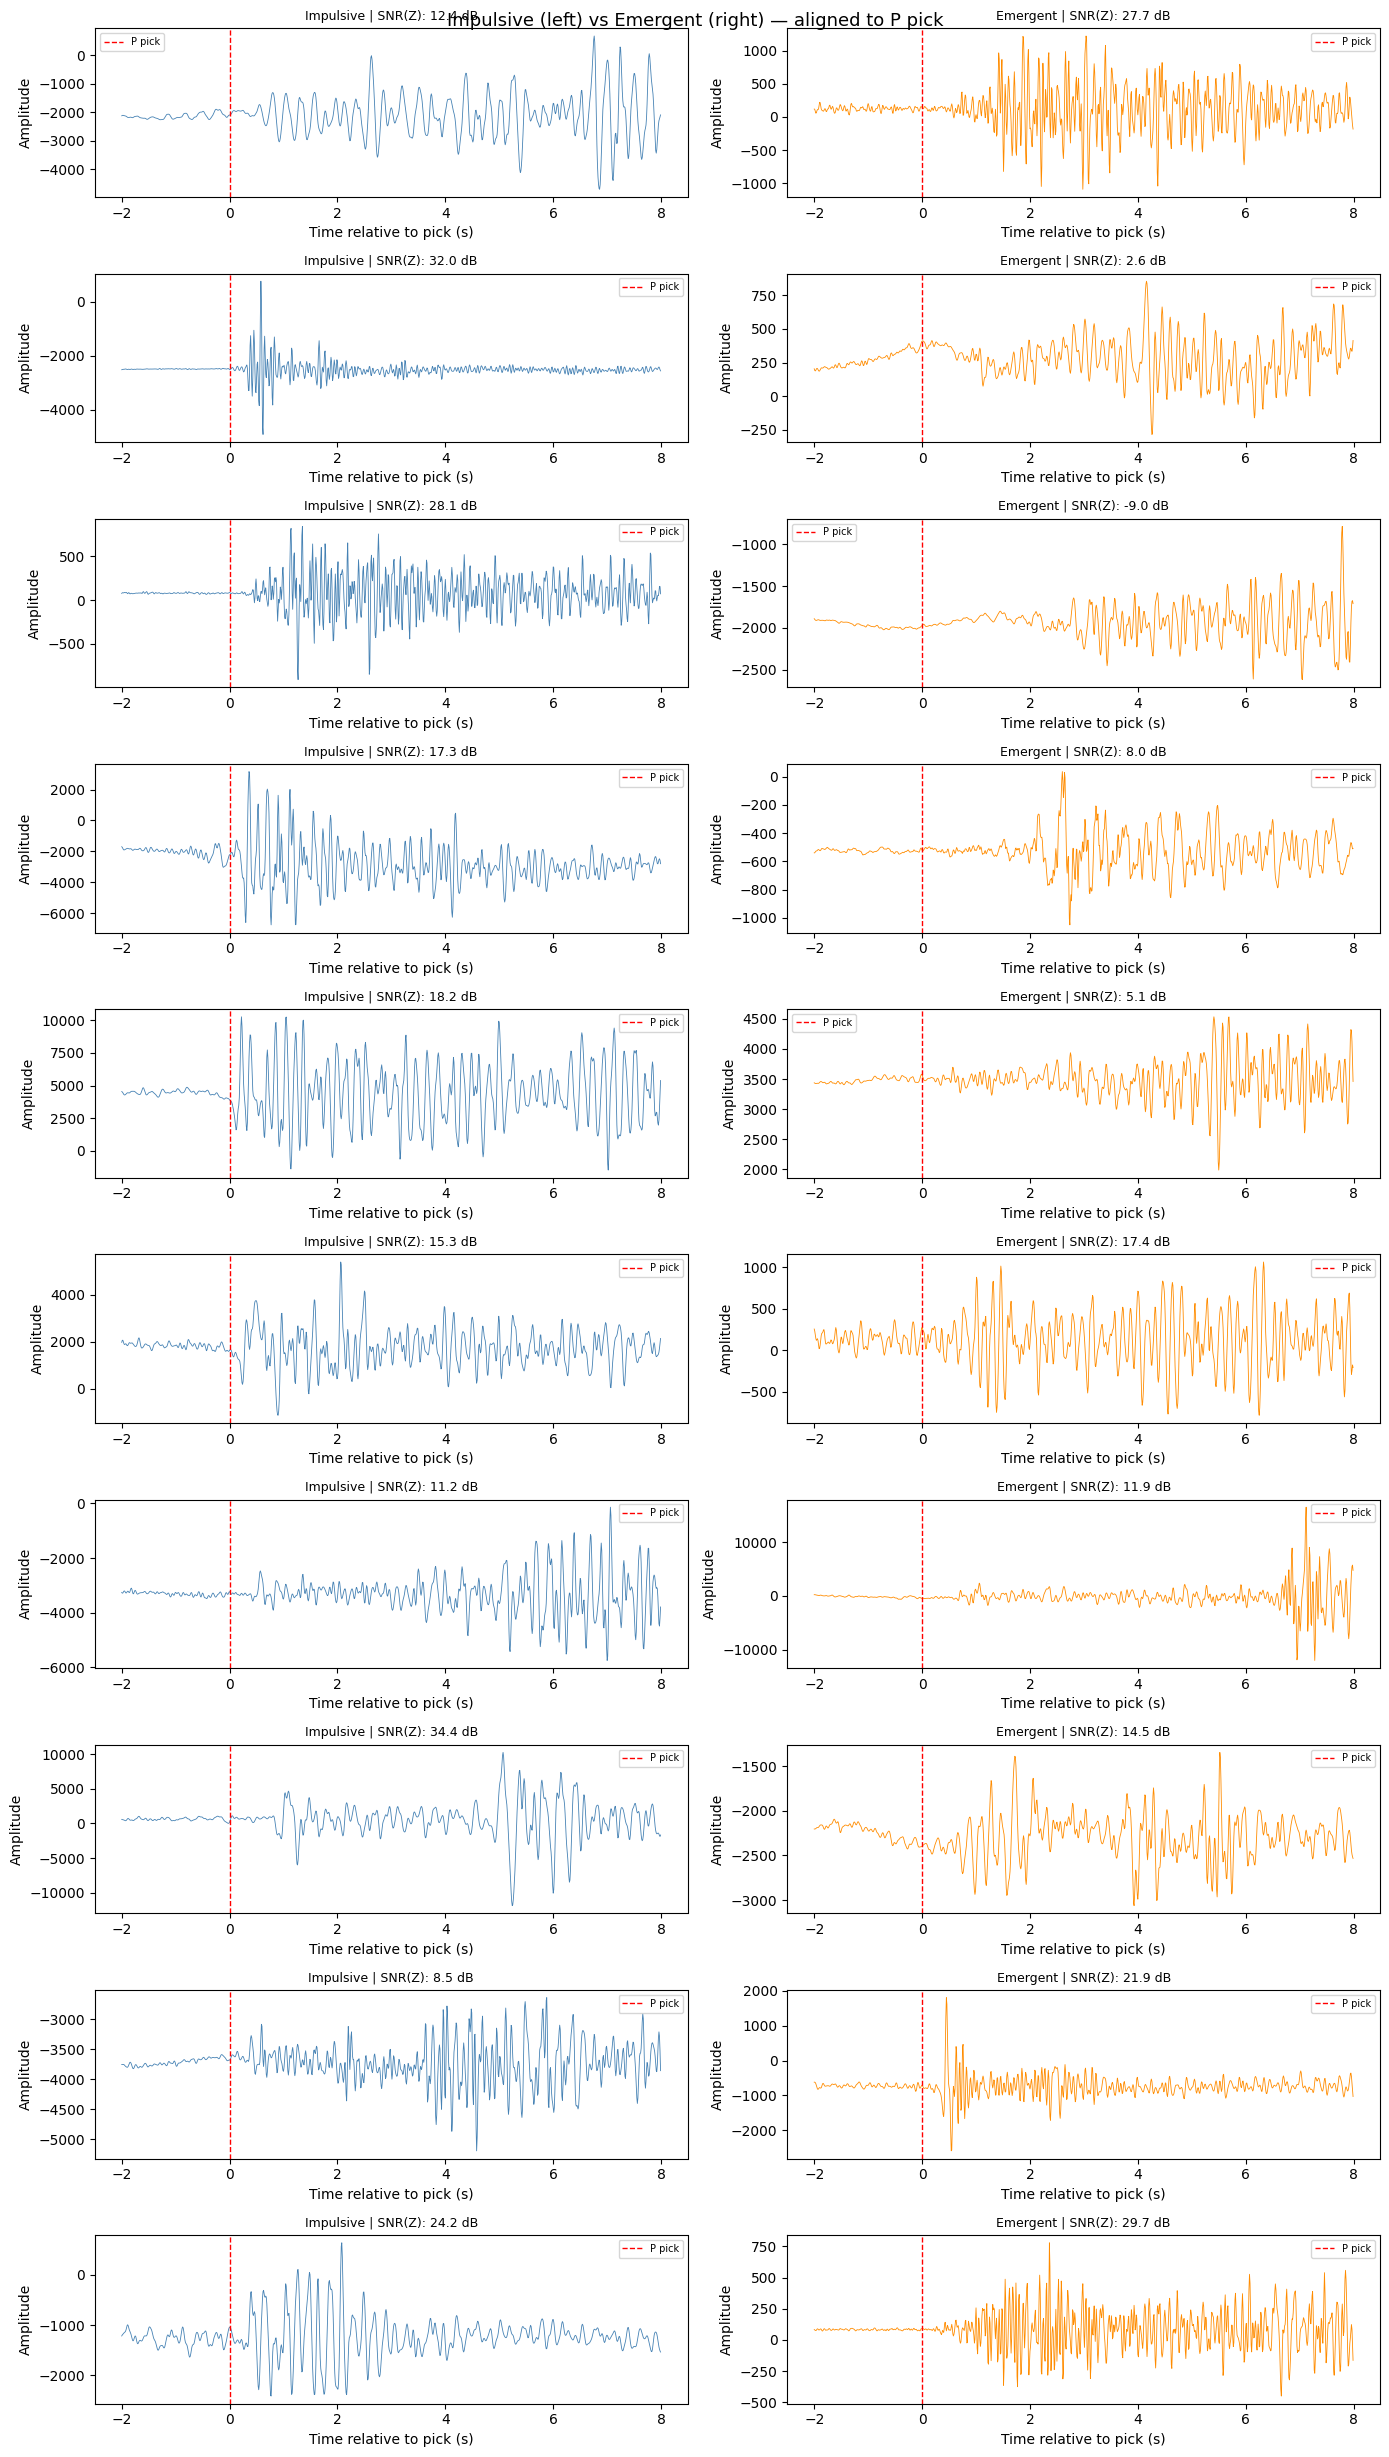

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def parse_trace_name(trace_name):
    """
    Parse trace_name like 'bucket1$0,:3,:18001'
    Returns bucket name and row index within that bucket.
    """
    parts = trace_name.split('$')
    bucket = parts[0]  # e.g. 'bucket1'
    row_idx = int(parts[1].split(',')[0])  # e.g. 0
    return bucket, row_idx

# Sample 10 from each class
n_examples = 10
imp_sample = impulsive.dropna(subset=['trace_P_arrival_sample']).sample(n_examples)
em_sample  = emergent.dropna(subset=['trace_P_arrival_sample']).sample(n_examples)


window_before = 200  # 2s at 100Hz
window_after  = 800  # 8s at 100Hz

fig, axes = plt.subplots(n_examples, 2, figsize=(14, n_examples * 2.5))
fig.suptitle("Impulsive (left) vs Emergent (right) — aligned to P pick", fontsize=13)

with h5py.File(file_exotic, 'r') as f:
    for i, (imp_row, em_row) in enumerate(zip(
        imp_sample.itertuples(), em_sample.itertuples()
    )):
        for ax, row, label, color in [
            (axes[i, 0], imp_row, 'Impulsive', 'steelblue'),
            (axes[i, 1], em_row,  'Emergent',  'darkorange')
        ]:
            bucket, row_idx = parse_trace_name(row.trace_name)
            
            # Z component is index 2 (E=0, N=1, Z=2)
            waveform = f[f'/data/{bucket}'][row_idx, 2, :]
            
            pick = int(row.trace_P_arrival_sample)
            start = max(0, pick - window_before)
            end   = min(len(waveform), pick + window_after)
            trace = waveform[start:end]
            
            t = (np.arange(len(trace)) - (pick - start)) / 100
            
            ax.plot(t, trace, color=color, linewidth=0.6)
            ax.axvline(0, color='red', linestyle='--', linewidth=1, label='P pick')
            ax.set_title(f"{label} | SNR(Z): {row.snr_Z:.1f} dB", fontsize=9)
            ax.set_xlabel("Time relative to pick (s)")
            ax.set_ylabel("Amplitude")
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [28]:
cat_su['trace_name'].values[0].split('$')[0]

'bucket1'

In [29]:
f['/data/bucket1'][0,2,:]

array([933.50103227, 931.75042616, 927.9992963 , ..., 901.99817477,
       917.500668  , 927.25013926])

In [22]:
f

'/data/whd02/niyiyu_data/PNWML/exotic/waveforms.hdf5'